# Análisis Exploratorio de Datos

### Importación de Módulos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
#df= pd.read_csv("../data/gen4ou_preview_dataset.csv")
df= pd.read_csv("../data/gen9ou_preview_dataset.csv")
df.head()

,battle_id,p1_poke1,p1_poke2,p1_poke3,p1_poke4,p1_poke5,p1_poke6,p2_poke1,p2_poke2,p2_poke3,p2_poke4,p2_poke5,p2_poke6,p1_win
0,1636793-gen9ou-2460221181,Dragapult,Kingambit,Hawlucha,Glimmora,Chesnaught,Gallade,Porygon-Z,Great Tusk,Raging Bolt,Corviknight,Meowscarada,Dragonite,1
1,1636793-gen9ou-2460221181,Porygon-Z,Great Tusk,Raging Bolt,Corviknight,Meowscarada,Dragonite,Dragapult,Kingambit,Hawlucha,Glimmora,Chesnaught,Gallade,0
2,95801-gen9ou-2513923983,Meganium,Arboliva,Avalugg,Ditto,Houndoom,Tinkaton,Hawlucha,Rillaboom,Azumarill,Iron Moth,Corviknight,Raging Bolt,1
3,95801-gen9ou-2513923983,Hawlucha,Rillaboom,Azumarill,Iron Moth,Corviknight,Raging Bolt,Meganium,Arboliva,Avalugg,Ditto,Houndoom,Tinkaton,0
4,1514712-gen9ou-2429668049,Dragonite,Zamazenta,Landorus-Therian,Gholdengo,Darkrai,Hatterene,Ninetales,Ceruledge,Venusaur,Hatterene,Great Tusk,Walking Wake,1


In [3]:
df.shape

df['p1_win'].value_counts(normalize=True)

p1_win
1    0.5
0    0.5
Name: proportion, dtype: float64

## 1. Análisis individual de Pokémon en el metajuego competitivo

### 1.1 Análisis de Frecuencia de Pokémon en el dataset

In [4]:
pokemon_cols = [
    "p1_poke1","p1_poke2","p1_poke3","p1_poke4","p1_poke5","p1_poke6",
    "p2_poke1","p2_poke2","p2_poke3","p2_poke4","p2_poke5","p2_poke6"
]

all_pokemon = pd.concat([df[col] for col in pokemon_cols])

freq = all_pokemon.value_counts()

freq.head(100)

Great Tusk      1824814
Kingambit       1319908
Gholdengo       1105740
Dragapult       1018224
Iron Valiant     885250
                 ...   
Slither Wing      83016
Manaphy           82494
Comfey            80956
Mamoswine         78734
Gyarados          76876
Name: count, Length: 100, dtype: int64

In [5]:
freq_percentage = (freq / len(all_pokemon)) * 100
freq_percentage.head(20)

Great Tusk            4.315472
Kingambit             3.121428
Gholdengo             2.614946
Dragapult             2.407981
Iron Valiant          2.093513
Slowking-Galar        2.013580
Dragonite             2.011863
Raging Bolt           1.935132
Ogerpon-Wellspring    1.931079
Corviknight           1.786343
Landorus-Therian      1.752554
Zamazenta             1.716683
Gliscor               1.697759
Cinderace             1.618380
Hatterene             1.566589
Iron Moth             1.403038
Kyurem                1.387326
Samurott-Hisui        1.349421
Glimmora              1.333685
Iron Treads           1.317907
Name: count, dtype: float64

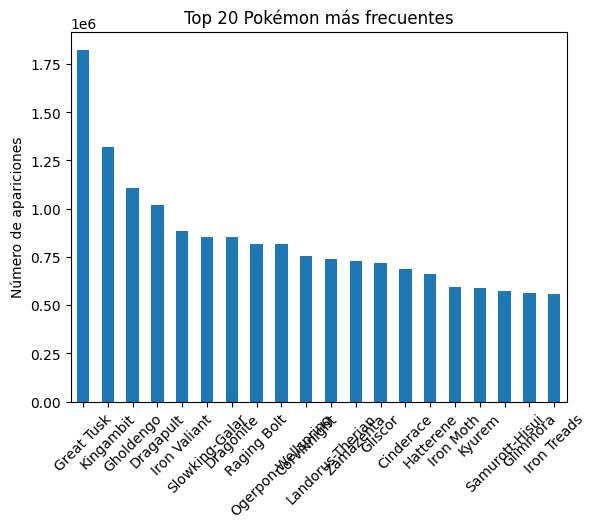

In [6]:
top_20 = freq.head(20)

plt.figure()
top_20.plot(kind="bar")
plt.title("Top 20 Pokémon más frecuentes")
plt.ylabel("Número de apariciones")
plt.xticks(rotation=45)
plt.show()

### 1.2 Análisis de Porcentaje de victorias por Pokémon

In [7]:
df["winning_team"] = df["p1_win"].apply(lambda x: 1 if x == 1 else 2)

records = []

for _, row in df.iterrows():
    
    # Equipo 1
    for col in ["p1_poke1","p1_poke2","p1_poke3","p1_poke4","p1_poke5","p1_poke6"]:
        records.append({
            "pokemon": row[col],
            "win": 1 if row["winning_team"] == 1 else 0
        })
    
    # Equipo 2
    for col in ["p2_poke1","p2_poke2","p2_poke3","p2_poke4","p2_poke5","p2_poke6"]:
        records.append({
            "pokemon": row[col],
            "win": 1 if row["winning_team"] == 2 else 0
        })

long_df = pd.DataFrame(records)

pokemon_stats = (
    long_df
    .groupby("pokemon")
    .agg(
        appearances=("win", "count"),
        wins=("win", "sum")
    )
)

pokemon_stats["winrate"] = pokemon_stats["wins"] / pokemon_stats["appearances"]

pokemon_stats.sort_values("winrate", ascending=False).head(20) 

,appearances,wins,winrate
pokemon,,,
Arceus-Water,4,4,1.000000
Arceus-Dark,2,2,1.000000
Mareep,2,2,1.000000
Charizard-Mega-X,2,2,1.000000
Poltchageist-Artisan,2,2,1.000000
Snubbull,4,4,1.000000
Quaxly,4,4,1.000000
Pikachu-Belle,2,2,1.000000
Heracross-Mega,2,2,1.000000


Aplicamos la Wilson Score Interval para obtener una medida más robusta de la tasa de victorias, especialmente para Pokémon con pocas apariciones. Esto nos permitirá identificar cuáles son los Pokémon más efectivos en combate, teniendo en cuenta tanto su tasa de victorias como la cantidad de veces que han participado en combates.

In [8]:
import numpy as np

def wilson_lower_bound(wins, n, z=1.96):  # 95% confidence
    if n == 0:
        return 0
    p = wins / n
    denominator = 1 + z**2 / n
    centre = p + z**2 / (2*n)
    margin = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n)
    return (centre - margin) / denominator

In [9]:
pokemon_stats["wilson_score"] = pokemon_stats.apply(
    lambda row: wilson_lower_bound(row["wins"], row["appearances"]),
    axis=1
)

pokemon_stats.sort_values("wilson_score", ascending=False).head(20)

,appearances,wins,winrate,wilson_score
pokemon,,,,
Tyranitar-Mega,16,14,0.875000,0.639767
Cyndaquil,384,250,0.651042,0.602085
Altaria-Mega,14,12,0.857143,0.600581
Shaymin-Sky,38,28,0.736842,0.579908
Calyrex-Ice,36,26,0.722222,0.560072
Slowbro-Mega,12,10,0.833333,0.551964
Terapagos,3622,2026,0.559359,0.543137
Chien-Pao,88,56,0.636364,0.532111
Cobalion,22822,12192,0.534221,0.527744


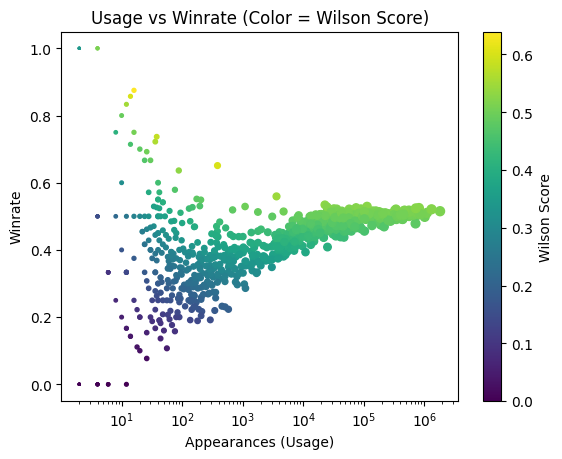

In [10]:
plt.figure()
s= np.log10(pokemon_stats["appearances"]) * 20

plt.scatter(
    pokemon_stats["appearances"],
    pokemon_stats["winrate"],  # tamaño burbuja
    s= s/3,  # tamaño burbuja
    c=pokemon_stats["wilson_score"],     # color
)

plt.colorbar(label="Wilson Score")

plt.xlabel("Appearances (Usage)")
plt.ylabel("Winrate")
plt.xscale("log")
plt.title("Usage vs Winrate (Color = Wilson Score)")

plt.show()

Se observa un patrón de dispersión en forma de embudo, indicativo de alta varianza en muestras pequeñas y convergencia hacia el equilibrio competitivo conforme aumenta el número de apariciones.

A medida que aumentamos el umbral de apariciones, la tasa de victorias de los Pokémon más comunes se vuelve más estable, mientras que los Pokémon con pocas apariciones pueden mostrar tasas de victorias extremas debido a la falta de datos, en este caso mostrando tasa de victorias promedio especialmente bajas bajando del umbral de las 10000 apariciones, lo que sugiere que los pokémon fuera del metagame establecido tienden a mostrar un rendimiento inferior debido a un metajuego mucho más establecido.

## 2. Análisis de combinaciones(cores) de Pokémon en el metajuego competitivo

### 2.1 Análisis de combinaciones frecuentes de Pokémon

In [11]:
unique_teams = df.drop_duplicates(subset="battle_id")

In [12]:
teams = []

for _, row in unique_teams.iterrows():
    team1 = [
        row["p1_poke1"], row["p1_poke2"], row["p1_poke3"],
        row["p1_poke4"], row["p1_poke5"], row["p1_poke6"]
    ]
    
    team2 = [
        row["p2_poke1"], row["p2_poke2"], row["p2_poke3"],
        row["p2_poke4"], row["p2_poke5"], row["p2_poke6"]
    ]
    
    teams.append(team1)
    teams.append(team2)

In [13]:
teams = []

for _, row in unique_teams.iterrows():
    team1 = [
        row["p1_poke1"], row["p1_poke2"], row["p1_poke3"],
        row["p1_poke4"], row["p1_poke5"], row["p1_poke6"]
    ]
    
    team2 = [
        row["p2_poke1"], row["p2_poke2"], row["p2_poke3"],
        row["p2_poke4"], row["p2_poke5"], row["p2_poke6"]
    ]
    
    teams.append(team1)
    teams.append(team2)

In [14]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

te = TransactionEncoder()
te_array = te.fit(teams).transform(teams)

teams_df = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(
    teams_df,
    min_support=0.02,  # por ejemplo 2% de los equipos
    use_colnames=True
)

frequent_itemsets["size"] = frequent_itemsets["itemsets"].apply(len)
combos = frequent_itemsets[frequent_itemsets["size"] >= 2].copy()
combos["combo"] = combos["itemsets"].apply(lambda x: tuple(sorted(list(x))))
combos["combo"] = combos["itemsets"].apply(lambda x: tuple(sorted(list(x))))
combos.sort_values("support", ascending=False).head(20)

,support,itemsets,size,combo
97,0.061204,"frozenset({Kingambit, Great Tusk})",2,"(Great Tusk, Kingambit)"
85,0.055513,"frozenset({Gholdengo, Great Tusk})",2,"(Gholdengo, Great Tusk)"
76,0.048322,"frozenset({Dragapult, Great Tusk})",2,"(Dragapult, Great Tusk)"
104,0.047277,"frozenset({Slowking-Galar, Great Tusk})",2,"(Great Tusk, Slowking-Galar)"
100,0.042482,"frozenset({Raging Bolt, Great Tusk})",2,"(Great Tusk, Raging Bolt)"
108,0.041312,"frozenset({Kingambit, Iron Valiant})",2,"(Iron Valiant, Kingambit)"
99,0.039193,"frozenset({Ogerpon-Wellspring, Great Tusk})",2,"(Great Tusk, Ogerpon-Wellspring)"
77,0.037291,"frozenset({Kingambit, Dragapult})",2,"(Dragapult, Kingambit)"
110,0.036018,"frozenset({Kingambit, Landorus-Therian})",2,"(Kingambit, Landorus-Therian)"
106,0.034564,"frozenset({Walking Wake, Great Tusk})",2,"(Great Tusk, Walking Wake)"


#### 2.2 Análisis de winrate de combinaciones frecuentes de Pokémon

In [15]:
unique_df = df.drop_duplicates(subset="battle_id")

teams_data = []

for _, row in unique_df.iterrows():
    
    team1 = {
        "pokemons": set([
            row["p1_poke1"], row["p1_poke2"], row["p1_poke3"],
            row["p1_poke4"], row["p1_poke5"], row["p1_poke6"]
        ]),
        "win": row["p1_win"]
    }
    
    team2 = {
        "pokemons": set([
            row["p2_poke1"], row["p2_poke2"], row["p2_poke3"],
            row["p2_poke4"], row["p2_poke5"], row["p2_poke6"]
        ]),
        "win": 1 - row["p1_win"]
    }
    
    teams_data.append(team1)
    teams_data.append(team2)

In [16]:
def compute_combo_winrate(combo, teams_data):
    total = 0
    wins = 0
    
    combo_set = set(combo)
    
    for team in teams_data:
        if combo_set.issubset(team["pokemons"]):
            total += 1
            wins += team["win"]
    
    if total == 0:
        return 0, 0
    
    return wins / total, total

In [17]:
winrates = []
appearances = []

for combo in combos["itemsets"]:
    wr, total = compute_combo_winrate(combo, teams_data)
    winrates.append(wr)
    appearances.append(total)

combos["combo_winrate"] = winrates
combos["combo_appearances"] = appearances

combos.sort_values("combo_winrate", ascending=False).head(20)

,support,itemsets,size,combo,combo_winrate,combo_appearances
114,0.024148,"frozenset({Zamazenta, Kingambit})",2,"(Kingambit, Zamazenta)",0.536143,85093
70,0.020200,"frozenset({Alomomola, Great Tusk})",2,"(Alomomola, Great Tusk)",0.534750,71179
90,0.024414,"frozenset({Gholdengo, Raging Bolt})",2,"(Gholdengo, Raging Bolt)",0.534547,86028
112,0.028763,"frozenset({Kingambit, Raging Bolt})",2,"(Kingambit, Raging Bolt)",0.532569,101354
110,0.036018,"frozenset({Kingambit, Landorus-Therian})",2,"(Kingambit, Landorus-Therian)",0.531141,126921
111,0.031475,"frozenset({Kingambit, Ogerpon-Wellspring})",2,"(Kingambit, Ogerpon-Wellspring)",0.529208,110911
92,0.023301,"frozenset({Zamazenta, Gholdengo})",2,"(Gholdengo, Zamazenta)",0.525406,82108
100,0.042482,"frozenset({Raging Bolt, Great Tusk})",2,"(Great Tusk, Raging Bolt)",0.525401,149699
113,0.031100,"frozenset({Kingambit, Slowking-Galar})",2,"(Kingambit, Slowking-Galar)",0.525107,109591
98,0.024752,"frozenset({Kyurem, Great Tusk})",2,"(Great Tusk, Kyurem)",0.525017,87222


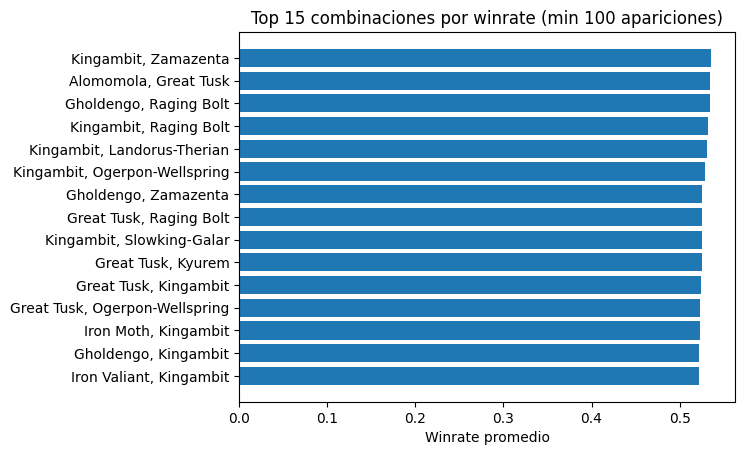

In [18]:
combos_strong = combos[
    (combos["combo_appearances"] > 100) &
    (combos["size"] <= 3)
].copy()


top_combos = combos_strong.sort_values(
    ["combo_winrate", "combo_appearances"],
    ascending=False
).head(15)

plt.figure()

plt.barh(
    top_combos["combo"].str.join(", "),
    top_combos["combo_winrate"]
)

plt.xlabel("Winrate promedio")
plt.title("Top 15 combinaciones por winrate (min 100 apariciones)")
plt.gca().invert_yaxis()

plt.show()

#### 2.3 Análisis de Pokémon más comunes en combinaciones más efectivas

In [19]:
winning_combos = combos[
    (combos["combo_winrate"] > 0.52) &
    (combos["combo_appearances"] > 100)
]

from collections import Counter

pokemon_counter = Counter()

for combo in winning_combos["itemsets"]:
    for poke in combo:
        pokemon_counter[poke] += 1

participation_df = pd.DataFrame.from_dict(
    pokemon_counter,
    orient="index",
    columns=["winning_combo_count"]
)

participation_df = participation_df.sort_values(
    "winning_combo_count",
    ascending=False
)

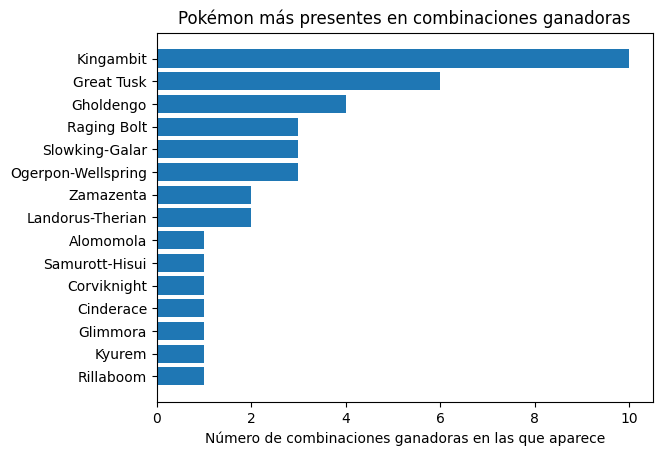

In [20]:
top_participants = participation_df.head(15)

plt.figure()

plt.barh(
    top_participants.index,
    top_participants["winning_combo_count"]
)

plt.xlabel("Número de combinaciones ganadoras en las que aparece")
plt.title("Pokémon más presentes en combinaciones ganadoras")
plt.gca().invert_yaxis()

plt.show()

Aunque individualmente presentan winrate cercano al equilibrio, ciertos Pokémon destacan por su alta participación en combinaciones estructuralmente ganadoras, lo que sugiere que su valor estratégico puede ser mayor cuando se consideran sinergias con otros Pokémon. Esto resalta la importancia de analizar no solo el rendimiento individual, sino también cómo los Pokémon interactúan en equipo para maximizar su efectividad en combate.

#### 2.4 Análisis de Synergy Winrate Gap

Definimos el Synergy Winrate Gap como la diferencia entre el winrate promedio de un pokémon en combinaciones  y su winrate individual. Este análisis nos permite identificar qué pokémon se benefician más de las sinergias en equipo, lo que puede ser crucial para la construcción de equipos efectivos en el metajuego competitivo. Un Synergy Winrate Gap positivo indica que un pokémon tiene un rendimiento significativamente mejor cuando se combina con ciertos compañeros, mientras que un gap negativo sugiere que el pokémon no se beneficia tanto de las sinergias y podría ser más efectivo por sí solo o con diferentes compañeros.

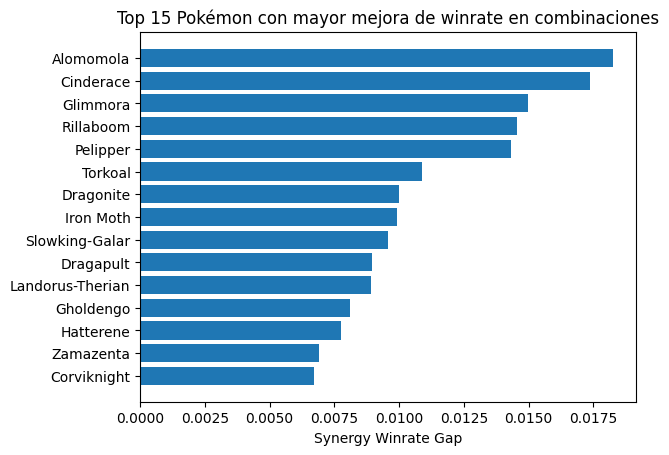

In [21]:
strong_combos = combos[
    (combos["combo_appearances"] > 100)
]

from collections import defaultdict
import numpy as np

combo_winrate_accumulator = defaultdict(list)

for _, row in strong_combos.iterrows():
    combo = row["itemsets"]
    wr = row["combo_winrate"]
    
    for poke in combo:
        combo_winrate_accumulator[poke].append(wr)

synergy_data = []

for poke, wr_list in combo_winrate_accumulator.items():
    synergy_data.append({
        "pokemon": poke,
        "combo_avg_winrate": np.mean(wr_list),
        "combo_count": len(wr_list)
    })

synergy_df = pd.DataFrame(synergy_data)

synergy_df = synergy_df.merge(
    pokemon_stats[["winrate"]],
    left_on="pokemon",
    right_index=True
)

synergy_df["synergy_winrate_gap"] = (
    synergy_df["combo_avg_winrate"] -
    synergy_df["winrate"]
)


top_synergy = synergy_df.sort_values(
    "synergy_winrate_gap",
    ascending=False
).head(15)

plt.figure()

plt.barh(
    top_synergy["pokemon"],
    top_synergy["synergy_winrate_gap"]
)

plt.xlabel("Synergy Winrate Gap")
plt.title("Top 15 Pokémon con mayor mejora de winrate en combinaciones")
plt.gca().invert_yaxis()

plt.show()

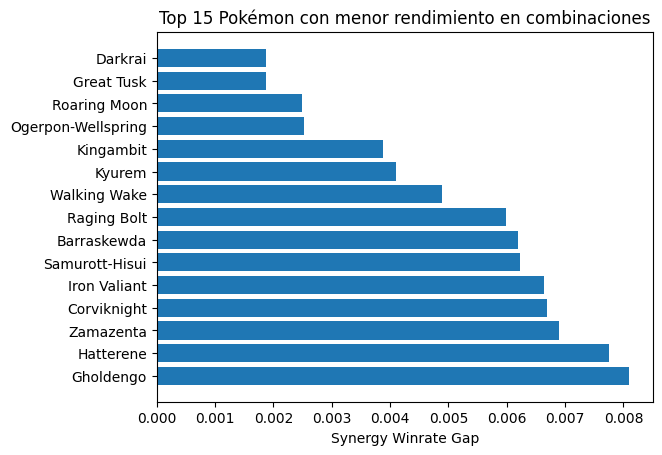

In [22]:
negative_synergy = synergy_df.sort_values(
    "synergy_winrate_gap",
    ascending=True
).head(15)

plt.figure()

plt.barh(
    negative_synergy["pokemon"],
    negative_synergy["synergy_winrate_gap"]
)

plt.xlabel("Synergy Winrate Gap")
plt.title("Top 15 Pokémon con menor rendimiento en combinaciones")
plt.gca().invert_yaxis()

plt.show()

## 3. Detección de datos perdidos y outliers

### 3.1 Detección de equipos incompletos

In [23]:
p1_cols = [f"p1_poke{i}" for i in range(1, 7)]
p2_cols = [f"p2_poke{i}" for i in range(1, 7)]

invalid_size_p1 = df[df[p1_cols].isnull().any(axis=1)]
invalid_size_p2 = df[df[p2_cols].isnull().any(axis=1)]

invalid_size_p1 += df[(df[p1_cols] == "").any(axis=1)]
invalid_size_p2 += df[(df[p2_cols] == "").any(axis=1)]

print(f"Equipos con tamaño inválido en p1: {len(invalid_size_p1)}")
print(f"Equipos con tamaño inválido en p2: {len(invalid_size_p2)}")


Equipos con tamaño inválido en p1: 0
Equipos con tamaño inválido en p2: 0


### 3.2 Detección de outliers 

#### 3.2.1 Detección Pokémon duplicados en el mismo equipo

In [24]:
def has_duplicates(row, cols):
    team = row[cols].tolist()
    return len(team) != len(set(team))

dup_p1 = df[df.apply(lambda row: has_duplicates(row, p1_cols), axis=1)]
dup_p2 = df[df.apply(lambda row: has_duplicates(row, p2_cols), axis=1)]

In [25]:
print(f"Equipos con Pokémon duplicados en p1: {len(dup_p1)}")
print(f"Equipos con Pokémon duplicados en p2: {len(dup_p2)}")

Equipos con Pokémon duplicados en p1: 0
Equipos con Pokémon duplicados en p2: 0


#### 3.2.2 Detección de Pokémon no reconocidos

In [26]:
pokemon_stats = pd.read_csv("../data/OUStats.csv")
valid_set = set(pokemon_stats["Name"])

In [27]:
all_pokemon_dataset = set(
    df[p1_cols + p2_cols].values.flatten()
)

unknown_pokemon = all_pokemon_dataset - valid_set
print(f"Pokémon no reconocidos en el dataset: {unknown_pokemon}")

Pokémon no reconocidos en el dataset: {'Pecharunt', 'Sinistcha-Masterpiece', 'Arceus-Dark', 'Oinkologne-F', 'Arceus-Bug', 'Giratina-Origin', 'Enamorus-Therian', 'Arceus-Ice', "Oricorio-Pa'u", 'Squawkabilly-Yellow', 'Squawkabilly-Blue', 'Lycanroc', 'Giratina', 'Tauros-Paldea-Combat', 'Ho-Oh', 'Arceus-Fairy', 'Tatsugiri', 'Flabébé', 'Basculin-White-Striped', 'Tauros-Paldea-Aqua', 'Palafin', 'Vivillon-Fancy', 'Shaymin-Sky', 'Lycanroc-Midnight', 'Oricorio-Pom-Pom', 'Basculegion-F', 'Pikachu-Sinnoh', 'Landorus-Therian', 'Deoxys-Defense', 'Thundurus', 'Landorus', 'Gimmighoul-Roaming', 'Meowstic-F', 'Vivillon-Pokeball', 'Shaymin', 'Sinistea-Antique', 'Dialga-Origin', 'Enamorus', 'Arceus-Fighting', 'Calyrex-Shadow', 'Pikachu-Belle', 'Pikachu-Unova', 'Pikachu-Alola', 'Charizard-Mega-Y', 'Maushold-Four', 'Pikachu-World', 'Lycanroc-Dusk', 'Calyrex-Ice', 'Meloetta', 'Deoxys-Speed', 'Thundurus-Therian', 'Deoxys-Attack', 'Basculin', 'Tornadus', 'Keldeo', 'Tornadus-Therian', 'Toxtricity-Low-Key', '

#### 3.2.3 Eliminación de Partidas con Mega Evoluciones

In [28]:
def has_mega(team):
    return any("-Mega" in poke for poke in team)

pokemon_cols = [c for c in df.columns if "poke" in c]

mask = df[pokemon_cols].apply(
    lambda row: any("-Mega" in str(p) for p in row),
    axis=1
)

df_no_megas = df[~mask]

In [29]:
banned_pokemon = {"Groudon-Primal", "Kyogre-Primal"}
mask = df_no_megas[pokemon_cols].isin(banned_pokemon).any(axis=1)

df_no_megas = df_no_megas[~mask].reset_index(drop=True)

print("Filas eliminadas:", mask.sum())
print("Filas restantes:", len(df_no_megas))

Filas eliminadas: 20
Filas restantes: 3523668


Ya que en esta generación no existen las mega evoluciones ni las formas primigenias, se eliminan las partidas que contienen mega evoluciones para evitar inconsistencias en el análisis y modelado posterior. La existencia de las mismas en el dataset se debe a la mezcla de datos entre diferentes modos de juego de singles, por lo tanto es necesario eliminar estas partidas para asegurar la homogeneidad del dataset y la validez de los análisis y modelos que se desarrollarán posteriormente.

#### 3.2.4 Tratamiento de Pokémon no reconocidos

In [30]:
import json

with open("../mapping/mapping.json", "r", encoding="utf-8") as f:
    mapping = json.load(f)

df_cleaned = df_no_megas.copy()

pokemon_cols = [
    "p1_poke1","p1_poke2","p1_poke3","p1_poke4","p1_poke5","p1_poke6",
    "p2_poke1","p2_poke2","p2_poke3","p2_poke4","p2_poke5","p2_poke6"
]

kept_pokemon = set()

def map_name(name):

    if name in mapping:
        entry = mapping[name]

        if entry["keep"]:
            kept_pokemon.add(name)
            return name
        
        else:
            return entry["target_name"]

    return name

for col in pokemon_cols:
    df_cleaned[col] = df_cleaned[col].apply(map_name)

kept_pokemon = sorted(list(kept_pokemon))

In [31]:
print("Pokemon que se mantienen sin cambiar nombre:")
print(kept_pokemon)
print(f"\nTotal: {len(kept_pokemon)}")

Pokemon que se mantienen sin cambiar nombre:
['Arceus-Bug', 'Arceus-Dark', 'Arceus-Fairy', 'Arceus-Fighting', 'Arceus-Ice', 'Arceus-Poison', 'Arceus-Psychic', 'Arceus-Water', 'Basculegion-F', 'Calyrex-Ice', 'Calyrex-Shadow', 'Hoopa', 'Hoopa-Unbound', 'Necrozma-Dawn-Wings', 'Necrozma-Dusk-Mane', 'Oricorio', "Oricorio-Pa'u", 'Oricorio-Pom-Pom', 'Oricorio-Sensu', 'Palafin', 'Pecharunt', 'Tauros-Paldea-Aqua', 'Tauros-Paldea-Blaze', 'Tauros-Paldea-Combat']

Total: 24


In [32]:
df_cleaned.to_csv("../data/gen9ou_cleaned_dataset.csv", index=False)

print("Dataset guardado en ../data/gen9ou_cleaned_dataset.csv")

Dataset guardado en ../data/gen9ou_cleaned_dataset.csv


Se aplica un mapeo manual para resolver los nombres de Pokémon que no coinciden con los del dataset de estadísticas.
Para ello se utiliza un archivo externo (`mapping.json`) que define, para cada especie no reconocida, el nombre equivalente en el dataset de estadísticas (`target_name`), si el nombre debe conservarse (`keep`) y, en caso necesario, la forma asociada (`form`).

Cuando `keep` es `false`, el nombre del Pokémon se reemplaza por su equivalente en el dataset de estadísticas. Cuando `keep` es `true`, el nombre original se mantiene y únicamente se registra la forma correspondiente. Estos casos se almacenan además en una lista para poder tratarlos posteriormente durante la generación de variables derivadas.




#### 3.2.5 Creación de dataset con reglas actuales de Gen 9 OU sin Ubers

In [33]:
df_actual_metagame = df_cleaned.copy()

UBERS = {
"Annihilape","Arceus","Arceus-Bug","Arceus-Dark","Arceus-Dragon","Arceus-Electric",
"Arceus-Fairy","Arceus-Fighting","Arceus-Fire","Arceus-Flying","Arceus-Ghost",
"Arceus-Grass","Arceus-Ground","Arceus-Ice","Arceus-Poison","Arceus-Psychic",
"Arceus-Rock","Arceus-Steel","Arceus-Water","Baxcalibur","Calyrex-Ice","Chi-Yu",
"Chien-Pao","DeoxysAttackAttack","Dialga","DialgaOriginOrigin","Espathra","Eternatus",
"Flutter Mane","GiratinaAlteredAltered","GiratinaOriginOrigin","Groudon","Ho-oh","Iron Bundle",
"Koraidon","Kyogre","Kyurem-Black","LandorusIncarnateIncarnate","Lunala","Magearna","Mewtwo",
"Necrozma-Dusk-Mane","Ogerpon-Hearthflame","Palafin","Palkia","PalkiaOriginOrigin",
"Rayquaza","Regieleki","Roaring Moon","Shaymin-SkySkySky","Spectrier","Terapagos",
"Ursaluna-Bloodmoon","Urshifu","Volcarona","Zacian", "Zamazenta",
"Zacian-Crowned","Zamazenta-Crowned","Zekrom"
}

mask_ubers = df_actual_metagame[pokemon_cols].isin(UBERS).any(axis=1)
removed_rows = mask_ubers.sum()
df_actual_metagame = df_actual_metagame[~mask_ubers].reset_index(drop=True)

# eliminar columna winning_team si existe
if "winning_team" in df_actual_metagame.columns:
    df_actual_metagame = df_actual_metagame.drop(columns=["winning_team"])

print("Filtrado completado")
print("Filas eliminadas:", removed_rows)
print("Filas restantes:", len(df_actual_metagame))

# guardar
df_actual_metagame.to_csv("../data/gen9ou_actual_metagame_03-26_cleaned_dataset.csv", index=False)

Filtrado completado
Filas eliminadas: 1093622
Filas restantes: 2430046


Con el fin de obtener un dataset representativo del metajuego actual (Marzo de 2026), se filtran las partidas para incluir únicamente aquellas que cumplen con las reglas de la generación 9 OU, excluyendo las partidas que contienen Pokémon actualmente clasificados como Ubers. 